<a href="https://colab.research.google.com/github/SadiaK-art/SadiaK-art.github.io/blob/main/SP_Unet_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**U-Net Architecture**
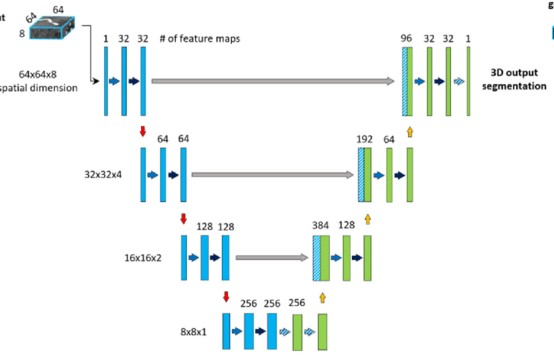

In [ ]:
#importing the libraries
!pip install patchify
!pip install segmentation_models

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 50 kB 6.3 MB/s 


In [ ]:
import os
import cv2
import numpy as np
import segmentation_models as sm
from patchify import patchify
from PIL import Image
from tensorflow.keras.metrics import MeanIoU
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from matplotlib import pyplot as plt
scaler=MinMaxScaler()

Segmentation Models: using `keras` framework.


In [ ]:
root_directory='/content/drive/MyDrive/Store patches'

patch_size=512

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
val='/content/drive/MyDrive/Semantic segmentation dataset/Tile 8/masks'.replace('masks','images')
print(val)

/content/drive/MyDrive/Semantic segmentation dataset/Tile 8/images


In [ ]:
#create patches of a bigger image using patchify library
image_dataset=[]
mask_dataset=[]
for path,subdirs,files in os.walk(root_directory):
  #print(path)
  dirname=path.split(os.path.sep)[-1]
  if dirname=='images':
    images=os.listdir(path)
    #print(images)
    for i,imagename in enumerate(images):
      print(imagename)
      if imagename.endswith('.jpg'):
        image=cv2.imread(path+'/'+imagename,1)
        #print(path+'/'+imagename)
        mask_path=path +'/'+imagename
        #print(mask_path)
        mask_path=mask_path.replace('.jpg','.png').replace('images','masks')
        #print(mask_path)
        #######################################
        #Reading corresponding mask
        mask=cv2.imread(mask_path,1)
        mask=cv2.cvtColor(mask,cv2.COLOR_BGR2RGB)
        ####image patching############
        size_x=(image.shape[1]//patch_size)*patch_size#Nearest size which is patchable
        size_y=(image.shape[0]//patch_size)*patch_size#Nearest size which is patchable
        ### mask patching#############
        size_x_m=(mask.shape[1]//patch_size)*patch_size
        size_y_m=(mask.shape[0]//patch_size)*patch_size
        #Now converting to a pil image
        image=Image.fromarray(image)
        mask=Image.fromarray(mask)
        #Now we just crop the image for creating patches for training
        image=image.crop((0,0,size_x,size_y))
        mask=mask.crop((0,0,size_x_m,size_y_m))
        #now converting image to a numpy array for easy understanding and visiblity
        image=np.array(image)
        mask=np.array(mask)
        #Now we will start patchifying the images
        print("Now patchifying image",path+"/"+imagename)
        patch_images=patchify(image,patch_size=(patch_size,patch_size,3),step=patch_size)
        print("Patchifying Masks",mask_path)
        patch_masks=patchify(mask,(patch_size,patch_size,3),step=patch_size)
        #Now setting all patched images in a dataset
        for i in range(patch_images.shape[0]):
          for j in range(patch_images.shape[1]):
            #getting single patch image and setting them in dataset array
            single_patch_img=patch_images[i,j,:,:]
            single_patch_img = scaler.fit_transform(single_patch_img.reshape(-1, single_patch_img.shape[-1])).reshape(single_patch_img.shape)
            #Dropping the extra unnecessary dimension
            single_patch_img=single_patch_img[0]
            image_dataset.append(single_patch_img)
        for p in range(patch_masks.shape[0]):
          for q in range(patch_masks.shape[1]):
            single_patch_mask=patch_masks[p,q,:,:]
            #droppping useless dimension
            single_patch_mask=single_patch_mask[0]
            mask_dataset.append(single_patch_mask)

In [ ]:
import glob
import cv2 as cv

imageset = []
maskset = []

image = glob.glob('/content/drive/MyDrive/Store patches/input 1/*.png')
mask = glob.glob('/content/drive/MyDrive/Store patches/mask 1/*.png')

for img in image:
    n = cv2.imread(img)
    imageset.append(n)
    
for msk in mask:
    n = cv2.imread(msk)
    maskset.append(n)
  

In [ ]:
#Now converting those two datasets into numpy array
imageset=np.array(imageset)
maskset=np.array(maskset)

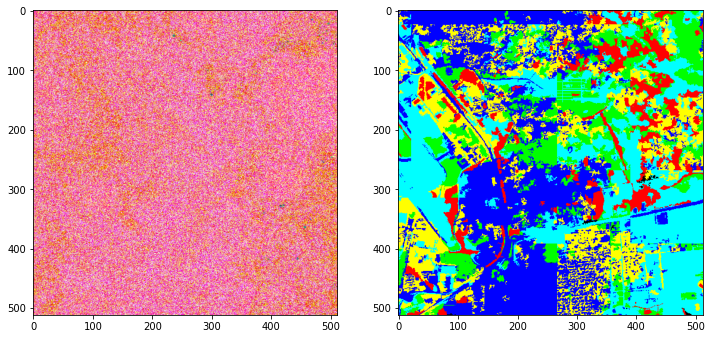

In [ ]:
#Now visualizing some images and their corresponding masks for sanity check
import random
image_num=random.randint(0,len(imageset))
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(np.reshape(imageset[image_num], (patch_size, patch_size, 3)))
plt.subplot(122)
plt.imshow(np.reshape(maskset[image_num], (patch_size, patch_size, 3)))
plt.show()

In [ ]:
#Now Hex to RGB Conversion
value=int('3C',base=16)
print(value)

60


In [ ]:
print(imageset.shape)

(15, 512, 512, 3)


In [ ]:
from time import sleep
import numpy as np
from PIL import Image
import cv2
def find_color_pixels(mask):
    #Using these function we will try to find out the uniques colors in a image
    #print("Finding the mask unique pixel values")
    new_shape_mask=np.unique(mask.reshape(-1,mask.shape[2]),axis=0)
    print(new_shape_mask)
    return new_shape_mask

#print("Image size: ",maskset.shape)
#Now finding unique pixel values
color_values=find_color_pixels(maskset)
cl_values=[[  0,0 ,0],
 [  0,0,255],
 [  0 ,255, 255],
 [255,0,0],
 [255,255,0]]
""""
cl_values=[[ 0,0,0],
 [ 0,0,233],
 [ 0,233,0],
 [ 0,233,233],
 [233,0,0],
 [233,233,0]]
"""
#print(cl_values)

#This function will help to take each label image as input and convert it from an image from merely an 2d array of 1s and 2s
def fill_values(image):
    label_image=np.zeros((image.shape[0],image.shape[1]))
    for i in range(0,image.shape[0]):
        for j in range(image.shape[1]):
          if np.array_equal(image[i,j,0],0) and np.array_equal(image[i,j,1],0) and np.array_equal(image[i,j,2],0): #BLACK = 0
            label_image[i,j]=0 
          if np.array_equal(image[i,j,0],0) and np.array_equal(image[i,j,1],0) and np.array_equal(image[i,j,2],255): #BLUE = 1
            label_image[i,j]=1
          if np.array_equal(image[i,j,0],0) and np.array_equal(image[i,j,1],255) and np.array_equal(image[i,j,2],255): #AQUA = 2
            label_image[i,j]=2
          if np.array_equal(image[i,j,0],255) and np.array_equal(image[i,j,1],0) and np.array_equal(image[i,j,2],0): #RED = 3
            label_image[i,j]=3
          if np.array_equal(image[i,j,0],255) and np.array_equal(image[i,j,1],255) and np.array_equal(image[i,j,2],0): #YELLOW = 4
            label_image[i,j]=4
    return label_image
#Final extension 
'''temp=maskset[row:,coloumext:,:]
print('Temp shape:', temp.shape)    
index=find_max_color(temp,cl_values)
rowext=temp.shape[0]
colext=temp.shape[1]
fill_values(index,row,coloumext,rowext,colext)
print('Temp shape:', label_image)'''

def find_max_color(im,cl):
    counter=[0,0,0,0,0]
    for h in range(im.shape[0]):
        for w in range(im.shape[1]):
            if np.array_equal(im[h, w, 0],cl[0][0]) and np.array_equal(im[h, w, 1],cl[0][1]) and np.array_equal(im[h, w, 2],cl[0][2]):
                counter[0]+=1
            elif np.array_equal(im[h, w, 0],cl[1][0]) and np.array_equal(im[h, w, 1],cl[1][1]) and np.array_equal(im[h, w, 2],cl[1][2]):
                counter[1]+=1
            elif np.array_equal(im[h, w, 0],cl[2][0]) and np.array_equal(im[h, w, 1],cl[2][1]) and np.array_equal(im[h, w, 2],cl[2][2]):
                counter[2]+=1
            elif np.array_equal(im[h, w, 0],cl[3][0]) and np.array_equal(im[h, w, 1],cl[3][1]) and np.array_equal(im[h, w, 2],cl[3][2]):
                counter[3]+=1
            elif np.array_equal(im[h, w, 0],cl[4][0]) and np.array_equal(im[h, w, 1],cl[4][1]) and np.array_equal(im[h, w, 2],cl[4][2]):
                counter[4]+=1
    max_index=counter.index(max(counter))
    return max_index

'''for row in range(maskset.shape[0]):
  for coloumext in range(maskset.shape[1]):
    temp=maskset[row:,coloumext:,:]  
    index=find_max_color(temp,cl_values)
    rowext=temp.shape[0]
    colext=temp.shape[1]
    n = fill_values(temp)
    label_images.append(n)

for row in range(maskset.shape[0]):
    for col in range(maskset.shape[1]):
        temp=maskset[row:row+512,col:col+512,:]
        index=find_max_color(temp,cl_values)
        rowext=temp.shape[0]
        colext=temp.shape[1]
        #print(index)
        fill_values(temp)
    temp=maskset[row:row+512,col:,:]
  
    index=find_max_color(temp,cl_values)
    rowext=temp.shape[0]
    colext=temp.shape[1]
    fill_values(temp)'''

[[  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0 255]
 [  0   0   0 ...   0   0 255]
 ...
 [255 255 255 ...   0 255 255]
 [255 255 255 ...   0 255   0]
 [255 255 255 ...   0 255   0]]


'for row in range(maskset.shape[0]):\n  for coloumext in range(maskset.shape[1]):\n    temp=maskset[row:,coloumext:,:]  \n    index=find_max_color(temp,cl_values)\n    rowext=temp.shape[0]\n    colext=temp.shape[1]\n    n = fill_values(temp)\n    label_images.append(n)\n\nfor row in range(maskset.shape[0]):\n    for col in range(maskset.shape[1]):\n        temp=maskset[row:row+512,col:col+512,:]\n        index=find_max_color(temp,cl_values)\n        rowext=temp.shape[0]\n        colext=temp.shape[1]\n        #print(index)\n        fill_values(temp)\n    temp=maskset[row:row+512,col:,:]\n  \n    index=find_max_color(temp,cl_values)\n    rowext=temp.shape[0]\n    colext=temp.shape[1]\n    fill_values(temp)'

In [ ]:
label_img = []
for i in range(15):
   n = fill_values(maskset[i])
   label_img.append(n)

print(label_img)

In [ ]:
#Now we will convert all the masks to labels
labels=[]
for i in range(maskset.shape[0]):
  temp_label=label_img[i]
  labels.append(temp_label)
#Now converting labels into a numpy array
labels=np.array(labels)
labels=np.expand_dims(labels,axis=3)

print("Unique labels in this dataset are ",np.unique(labels))

Unique labels in this dataset are  [0. 1. 2. 3. 4.]


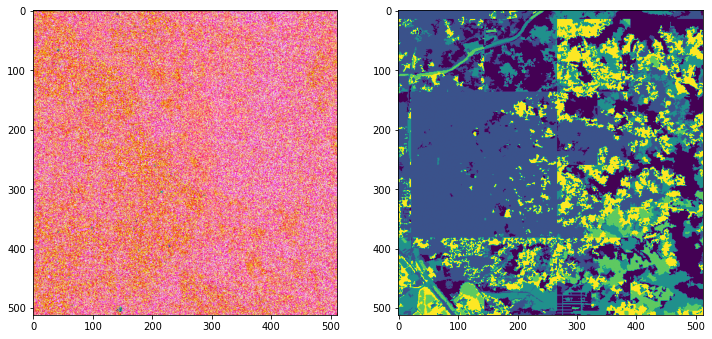

In [ ]:
#Another sanity check
import random
import numpy as np
image_number = random.randint(0, len(imageset))
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(imageset[7])
plt.subplot(122)
plt.imshow(labels[7][:,:,0])
plt.show()

In [ ]:
#Now one hot encoding format will be used by me.
num_classes=len(np.unique(labels))
print(num_classes)
from tensorflow.keras.utils import to_categorical
labels_cat=to_categorical(labels,num_classes=num_classes)

5


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(imageset,labels_cat,test_size=0.20,random_state=42)
image_dataset=[]
mask_dataset=[]
labels=[]

In [ ]:
#Now determining loss function and weights
weights=[0.1666,0.1666,0.1666,0.16666,0.16666,0.16666]

dice_loss=sm.losses.DiceLoss(class_weights=weights)
focal_loss=sm.losses.CategoricalFocalLoss()
total_loss=dice_loss+(1*focal_loss)


In [ ]:
img_height=x_train.shape[1]
img_width=x_train.shape[2]
img_channels=x_train.shape[3]
#Checking everything
print(x_train.shape)

(12, 512, 512, 3)


In [ ]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda
from keras import backend as K

def jacard_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) - intersection + 1.0)



################################################################
def multi_unet_model(n_classes=5, IMG_HEIGHT=512, IMG_WIDTH=512, IMG_CHANNELS=3):
#Build the model
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    s = Lambda(lambda x: x / 255)(inputs)   #No need for this if we normalize our inputs beforehand
    s = inputs

    #Contraction path
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(s)
    c1 = Dropout(0.2)(c1)  # Original 0.1
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = Dropout(0.2)(c2)  # Original 0.1
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)
     
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)
     
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)
     
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    
    #Expansive path 
    u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
     
    u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
     
    u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = Dropout(0.2)(c8)  # Original 0.1
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
     
    u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = Dropout(0.2)(c9)  # Original 0.1
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
     
    outputs = Conv2D(n_classes, (1, 1), activation='softmax')(c9)
     
    model = Model(inputs=[inputs], outputs=[outputs])
    
    #NOTE: Compile the model in the main program to make it easy to test with various loss functions
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    model.summary()
    
    return model

In [ ]:
#Now defining metrices for your evaluation
metrics=['accuracy',jacard_coef]

In [ ]:
model = multi_unet_model()

In [ ]:
#Now running the model
history1=model.fit(x_train,y_train,batch_size=8,verbose=1,epochs=100,validation_data=(x_test,y_test),shuffle=False)

Epoch 1/100
2/2 [==============================] - 19s 4s/step - loss: 57.2401 - accuracy: 0.2013 - val_loss: 14.1432 - val_accuracy: 0.2244
Epoch 2/100
2/2 [==============================] - 1s 242ms/step - loss: 23.6811 - accuracy: 0.2214 - val_loss: 10.0675 - val_accuracy: 0.2389
Epoch 3/100
2/2 [==============================] - 1s 218ms/step - loss: 16.1908 - accuracy: 0.2469 - val_loss: 8.5645 - val_accuracy: 0.2450
Epoch 4/100
2/2 [==============================] - 1s 217ms/step - loss: 12.4512 - accuracy: 0.2581 - val_loss: 6.7518 - val_accuracy: 0.2442
Epoch 5/100
2/2 [==============================] - 1s 218ms/step - loss: 9.6895 - accuracy: 0.2563 - val_loss: 5.1733 - val_accuracy: 0.2391
Epoch 6/100
2/2 [==============================] - 1s 212ms/step - loss: 7.6110 - accuracy: 0.2482 - val_loss: 3.9789 - val_accuracy: 0.2321
Epoch 7/100
2/2 [==============================] - 1s 217ms/step - loss: 6.0792 - accuracy: 0.2380 - val_loss: 3.1413 - val_accuracy: 0.2245
Epoch 8/1

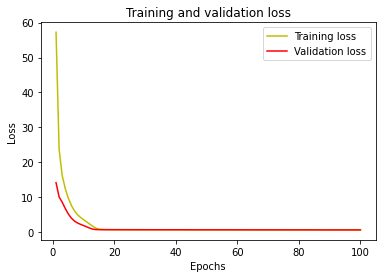

In [ ]:
from matplotlib import pyplot as plt

#Now visualizing training and validation loss
train_loss=history1.history['loss']
val_loss=history1.history['val_loss']
epochs=range(1,len(train_loss)+1)
plt.plot(epochs,train_loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Sadia and Sayad now your work will be to convert each patch image using this fill_values and make insert them in a list then convert that list to a numpy array.
#Then just normal model running procedure 